# $Импортирование\;необходимых\;библиотек$

In [20]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# $Настройка\;отображения$

In [21]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

DATA_PATH = 'data/feature_time_48k_2048_load_1.csv'
IMG_PATH = './figure/'
if not os.path.exists(IMG_PATH): os.mkdir(IMG_PATH)
feature_cols = ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form']
target_col = 'fault'

STRICT_COLS = ['mean', 'sd', 'rms']
SOFT_COLS = ['max', 'min', 'skewness', 'kurtosis', 'crest', 'form']
CLIP_STRICT = (0.01, 0.99)
CLIP_SOFT   = (0.005, 0.995)
NOISE_LEVELS = [0.01, 0.05, 0.10]

# $Чтение\;датасета\;из\;csv\;файла$

In [22]:
df = pd.read_csv(DATA_PATH) 
df

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.3599,-0.4189,0.0178,0.1227,0.1240,-0.1186,-0.0422,2.9019,6.9509,Ball_007_1
1,0.4677,-0.3611,0.0223,0.1325,0.1343,0.1747,-0.0815,3.4823,6.0352,Ball_007_1
2,0.4686,-0.4381,0.0205,0.1497,0.1510,0.0403,-0.2741,3.1028,7.3769,Ball_007_1
3,0.5847,-0.5430,0.0210,0.1571,0.1584,-0.0233,0.1347,3.6911,7.5584,Ball_007_1
4,0.4469,-0.5789,0.0222,0.1382,0.1399,-0.0815,0.4028,3.1936,6.3121,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.2142,-0.1984,0.0108,0.0641,0.0650,-0.2125,-0.1193,3.2970,6.0342,Normal_1
2296,0.2197,-0.2088,0.0131,0.0687,0.0699,-0.0613,-0.2951,3.1434,5.3200,Normal_1
2297,0.2080,-0.2161,0.0126,0.0671,0.0683,-0.1548,-0.0714,3.0462,5.4313,Normal_1
2298,0.2142,-0.2240,0.0126,0.0668,0.0680,-0.3270,0.0237,3.1518,5.3917,Normal_1


In [23]:
df['fault'].unique()

array(['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1',
       'IR_021_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1', 'Normal_1'],
      dtype=object)

In [24]:
print(f"Размер данных: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

Размер данных: (2300, 10)
Колонки: ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form', 'fault']


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_class_imbalance(df, target_col, save_prefix="imbalance"):
    counts = df[target_col].value_counts().sort_values(ascending=False)
    shares = (counts / counts.sum() * 100).round(2)

    result = pd.DataFrame({
        "class": counts.index.astype(str),
        "count": counts.values,
        "share_%": shares.values
    })

    max_count = counts.max()
    min_count = counts.min()
    imbalance_ratio = round(max_count / min_count, 2) if min_count > 0 else None

    print("Распределение классов:")
    print(result.to_string(index=False))
    print(f"\nКоэффициент дисбаланса (max/min): {imbalance_ratio}")

    result.to_csv(f"{save_prefix}_class_distribution.csv", index=False)
    return result, imbalance_ratio
result_df, ratio = analyze_class_imbalance(df, target_col="fault")

Распределение классов:
     class  count  share_%
Ball_007_1    230  10.0000
Ball_014_1    230  10.0000
Ball_021_1    230  10.0000
  IR_007_1    230  10.0000
  IR_014_1    230  10.0000
  IR_021_1    230  10.0000
OR_007_6_1    230  10.0000
OR_014_6_1    230  10.0000
OR_021_6_1    230  10.0000
  Normal_1    230  10.0000

Коэффициент дисбаланса (max/min): 1.0


# $Визуализация\;распределения\;признаков$

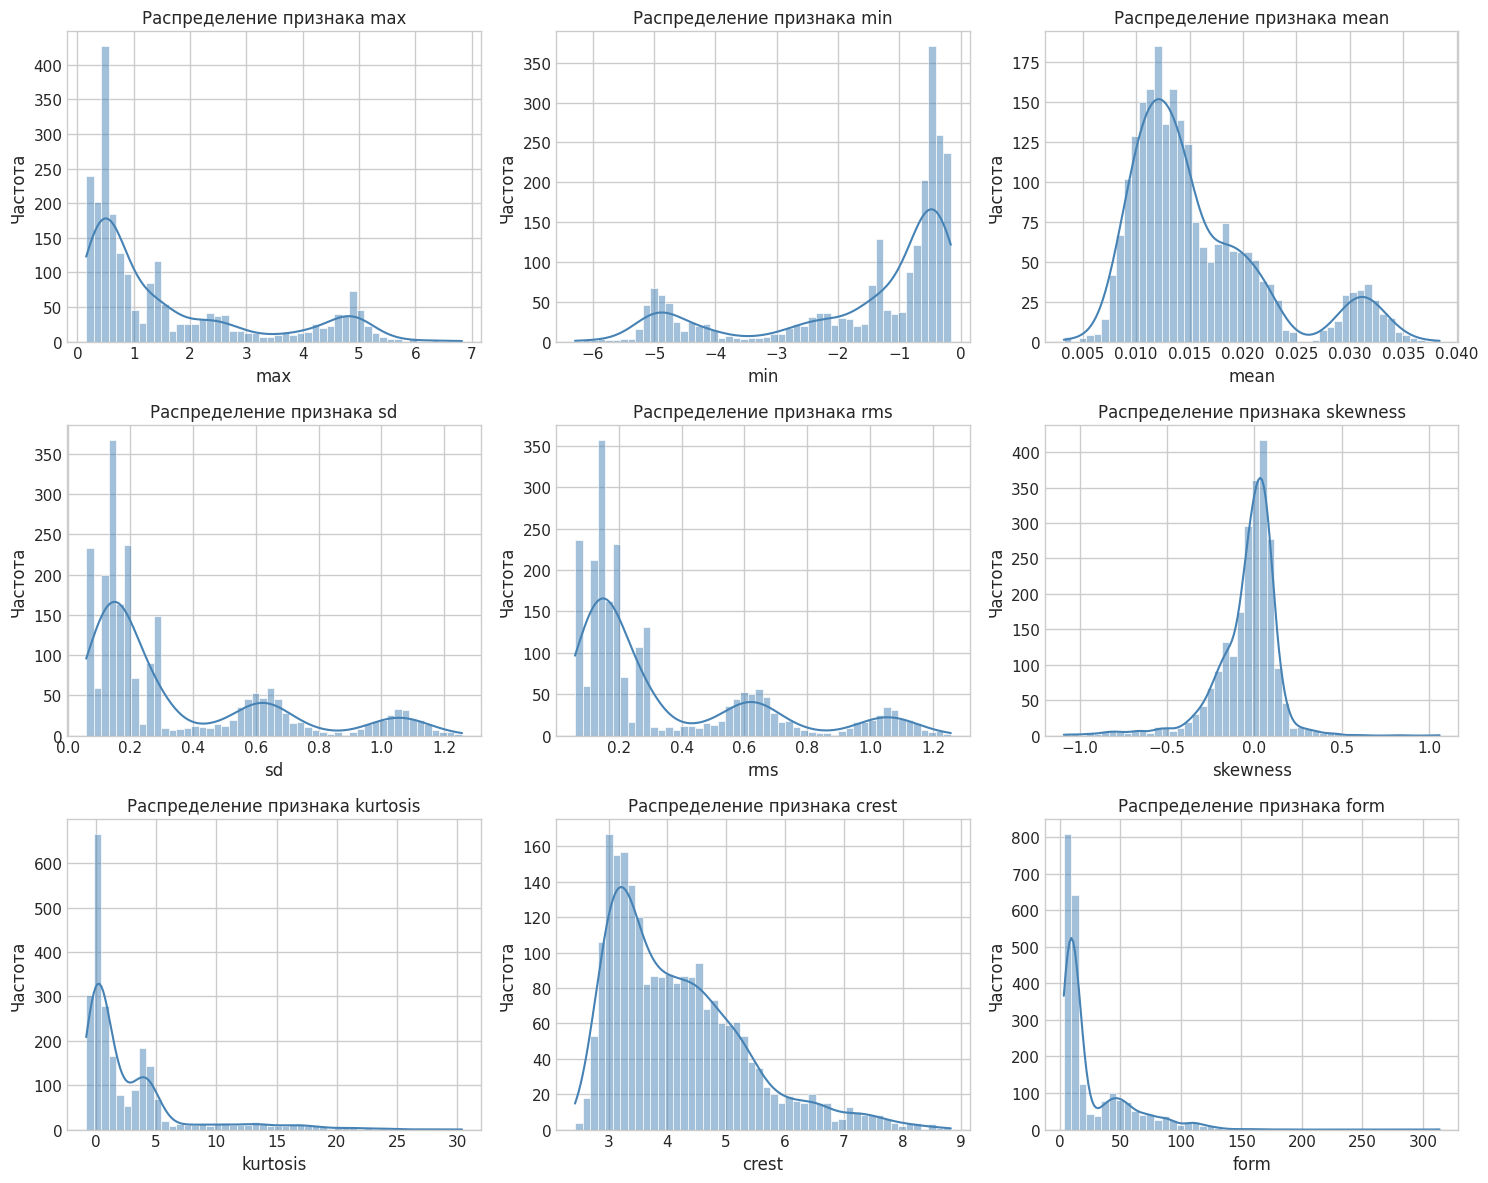

In [26]:
assert all(col in df.columns for col in feature_cols), "Не все признаки найдены"

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=50, color='steelblue')
    axes[i].set_title(f'Распределение признака {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.savefig(IMG_PATH + 'figure_1_distributions.png', dpi=150)
plt.show()

# $Визуализация\;взаимосвязей\;признаков$

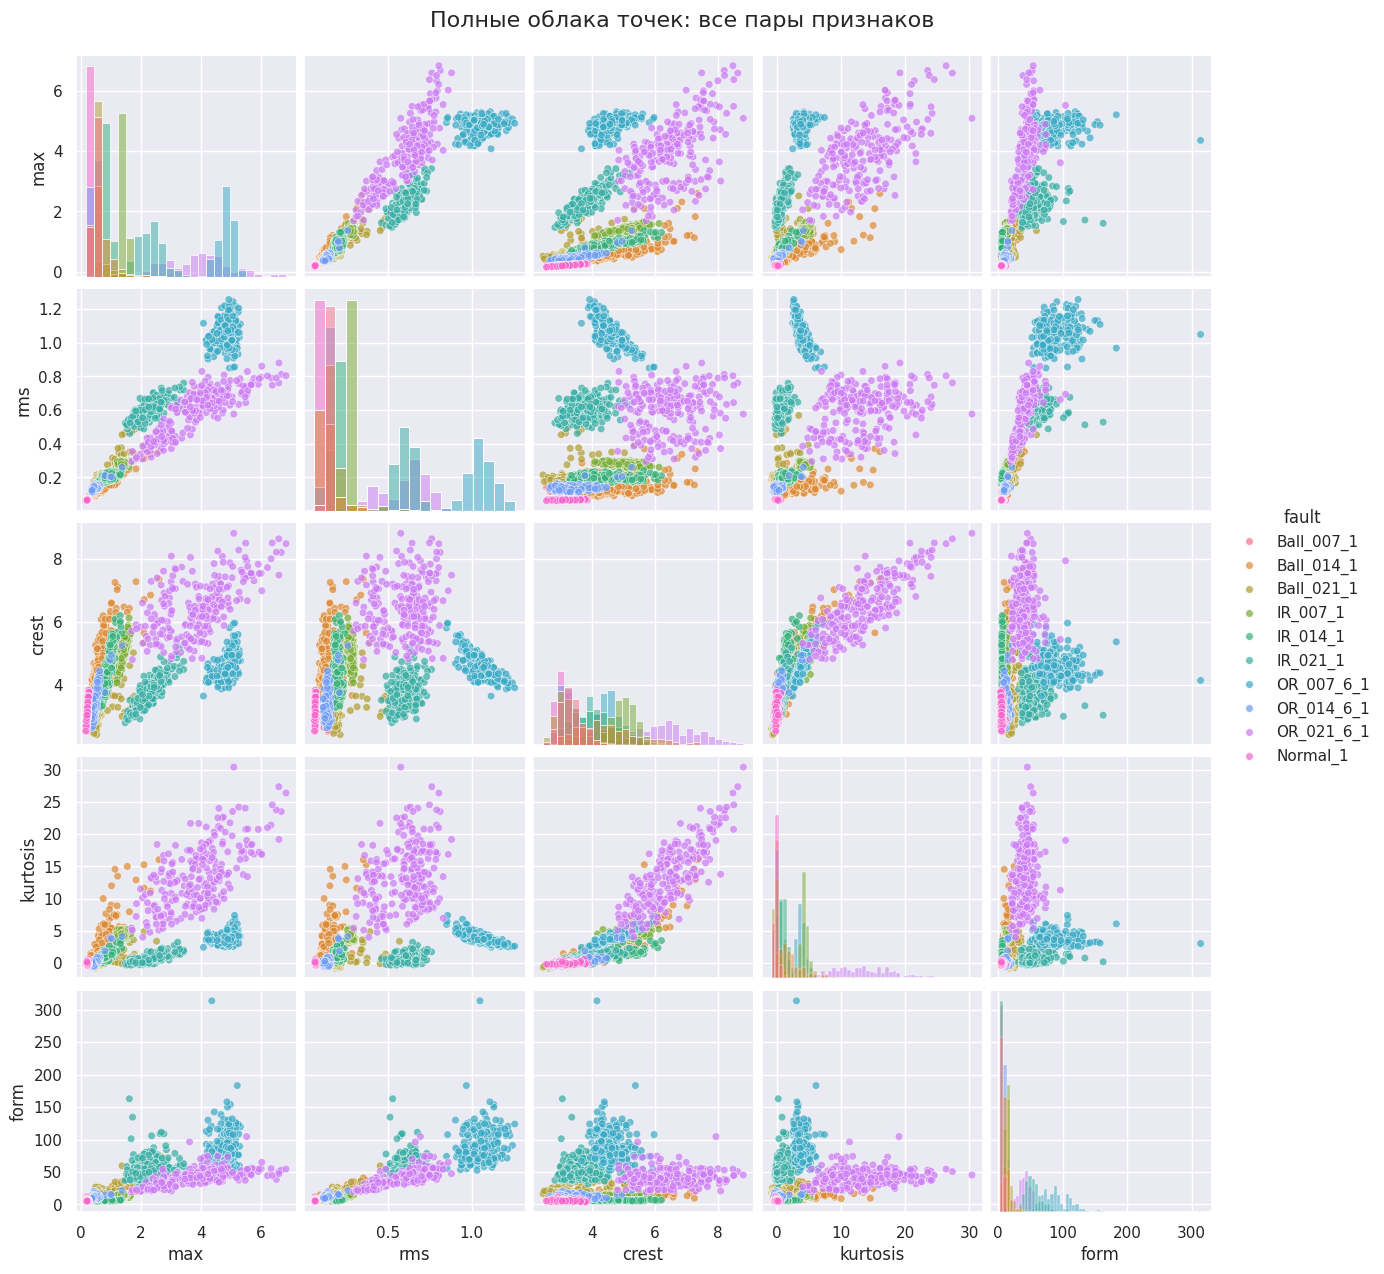

In [27]:
sns.set_theme(style="darkgrid")

# только 4–5 самых важных признаков, чтобы не перегружать
few_features = ["max", "rms", "crest", "kurtosis", "form"]

sns.pairplot(
    df[few_features + [target_col]],
    hue=target_col,
    palette="husl",
    plot_kws={"s": 30, "alpha": 0.7},
    diag_kind="hist"
)
plt.suptitle("Полные облака точек: все пары признаков", fontsize=16, y=1.02)
plt.savefig(IMG_PATH + 'figure_2_scatter_matrix.png', dpi=150)
plt.show()

# $Анализ\;на\;наличие\;пропусков$

In [28]:
missing_counts = df[feature_cols + [target_col]].isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_table = pd.DataFrame({
    'Признак': missing_counts.index,
    'Количество пропусков': missing_counts.values,
    'Доля пропусков, %': missing_percent.values
})

missing_table.to_csv('table_1_missing.csv', index=False)

print("\nТаблица 1. Количество и доля пропущенных значений по признакам")
missing_table


Таблица 1. Количество и доля пропущенных значений по признакам


,Признак,Количество пропусков,"Доля пропусков, %"
0,max,0,0.0000
1,min,0,0.0000
2,mean,0,0.0000
3,sd,0,0.0000
4,rms,0,0.0000
5,skewness,0,0.0000
6,kurtosis,0,0.0000
7,crest,0,0.0000
8,form,0,0.0000
9,fault,0,0.0000


# $Корреляционный\;анализ$

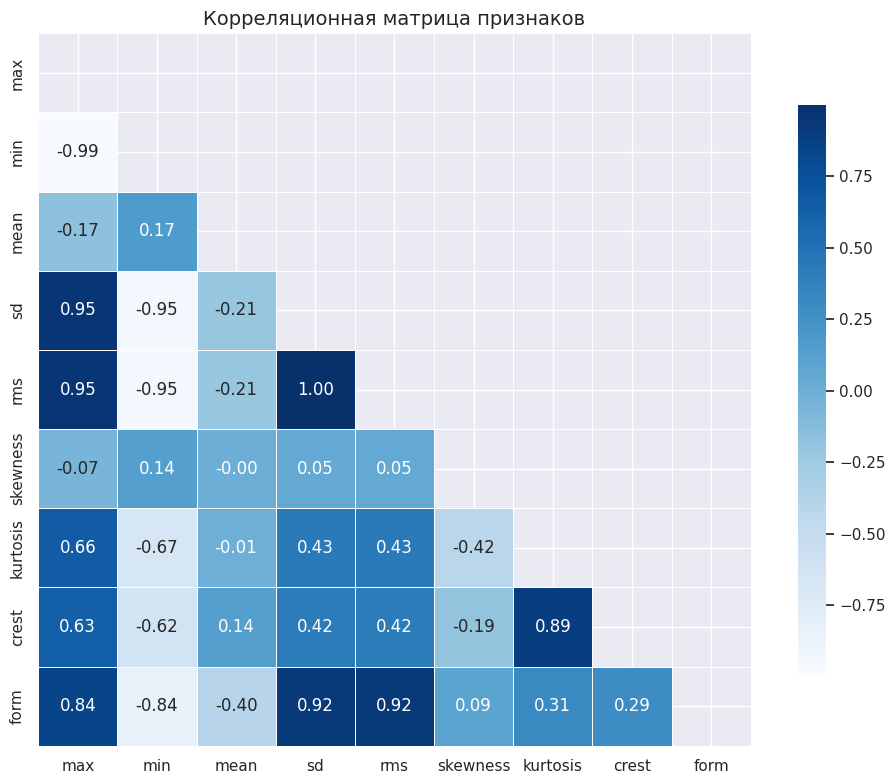


Наиболее сильные корреляции (|r| > 0.9):
  rms — sd: 1.000
  min — max: -0.993
  sd — max: 0.952
  rms — max: 0.952
  sd — min: -0.947


In [29]:
corr_matrix = df[feature_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=sns.color_palette("Blues", as_cmap=True), 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.savefig(IMG_PATH + 'figure_3_correlation_heatmap.png', dpi=150)
plt.show()

corr_stacked = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_stacked = corr_stacked.unstack().dropna().sort_values(key=abs, ascending=False)
print("\nНаиболее сильные корреляции (|r| > 0.9):")
for (i, j), val in corr_stacked.head(5).items():
    print(f"  {i} — {j}: {val:.3f}")

# $Устранение\;дубликатов$

In [30]:
full_dups = df.duplicated(subset=feature_cols + [target_col], keep='first').sum()

feature_dups = df.duplicated(subset=feature_cols, keep='first').sum()

feature_dups_total = df.duplicated(subset=feature_cols, keep=False).sum() - full_dups

dup_table = pd.DataFrame({
    'Тип дубликатов': ['Полные дубликаты (все признаки + target)', 
                       'Дубликаты только по признакам (без target)'],
    'Количество': [full_dups, feature_dups_total]
})
dup_table.to_csv('table_2_dup_table.csv', index=False)
df_clean = df
if any(dup_table['Количество'] != 0):
    df_clean = df.drop_duplicates(subset=feature_cols + [target_col], keep='first')
    print(f"Размер после удаления полных дубликатов: {df_clean.shape}")

print("\nТаблица 2. Количество дублированных записей")
dup_table


Таблица 2. Количество дублированных записей


,Тип дубликатов,Количество
0,Полные дубликаты (все признаки + target),0
1,Дубликаты только по признакам (без target),0


# $Анализ\;выбросов$

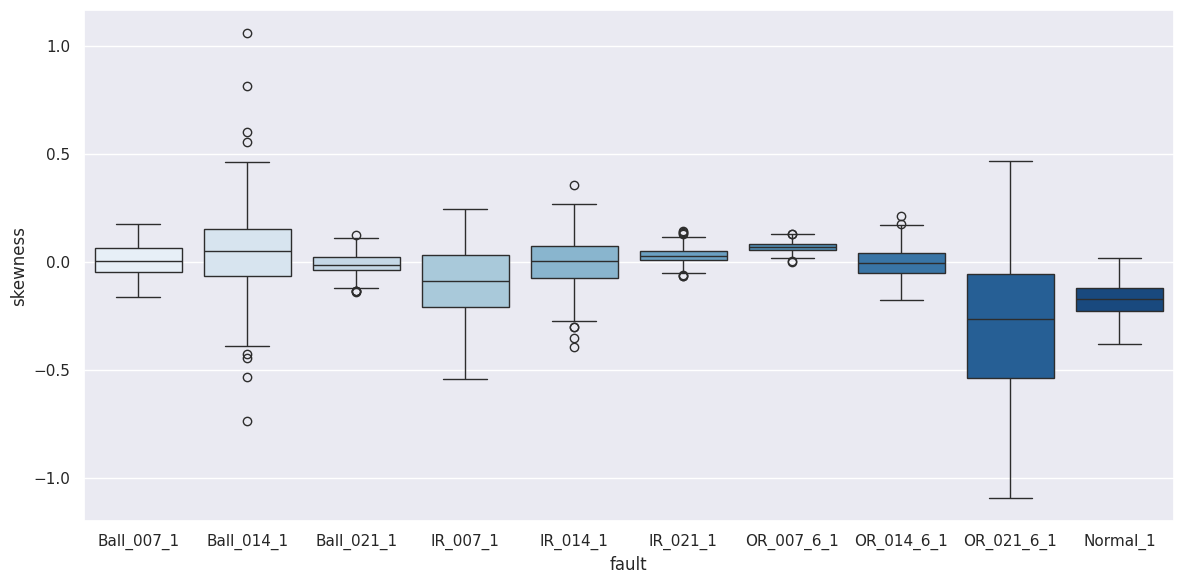

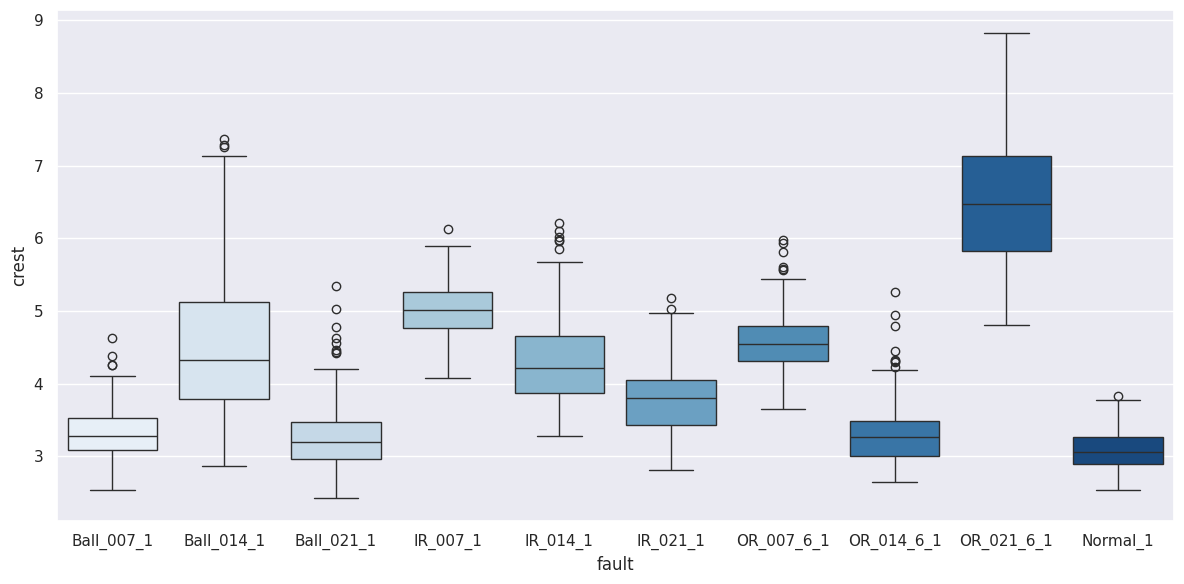

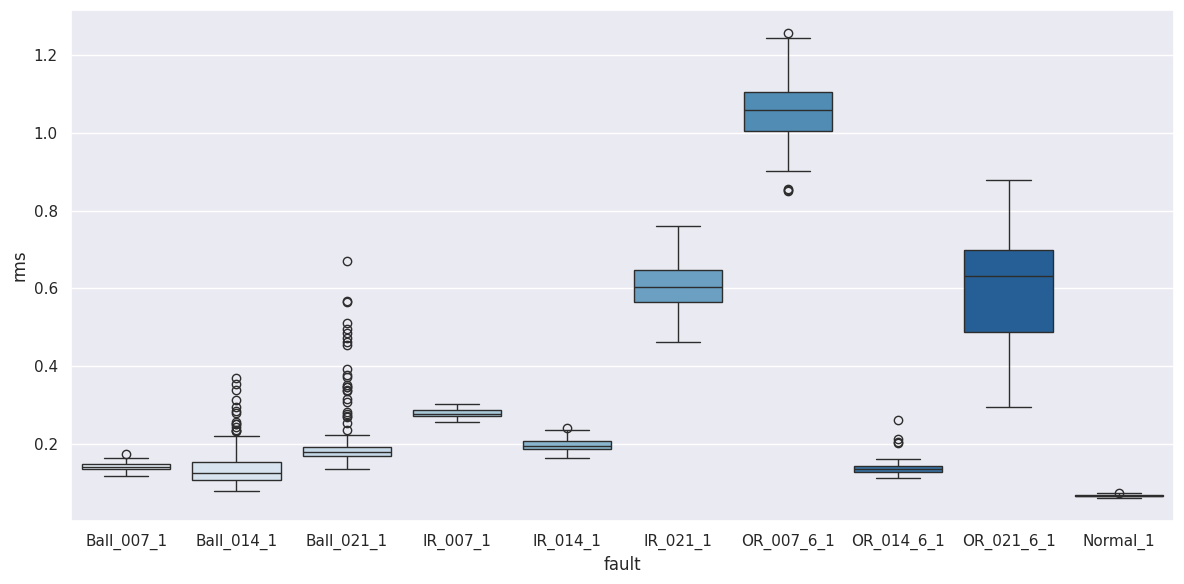

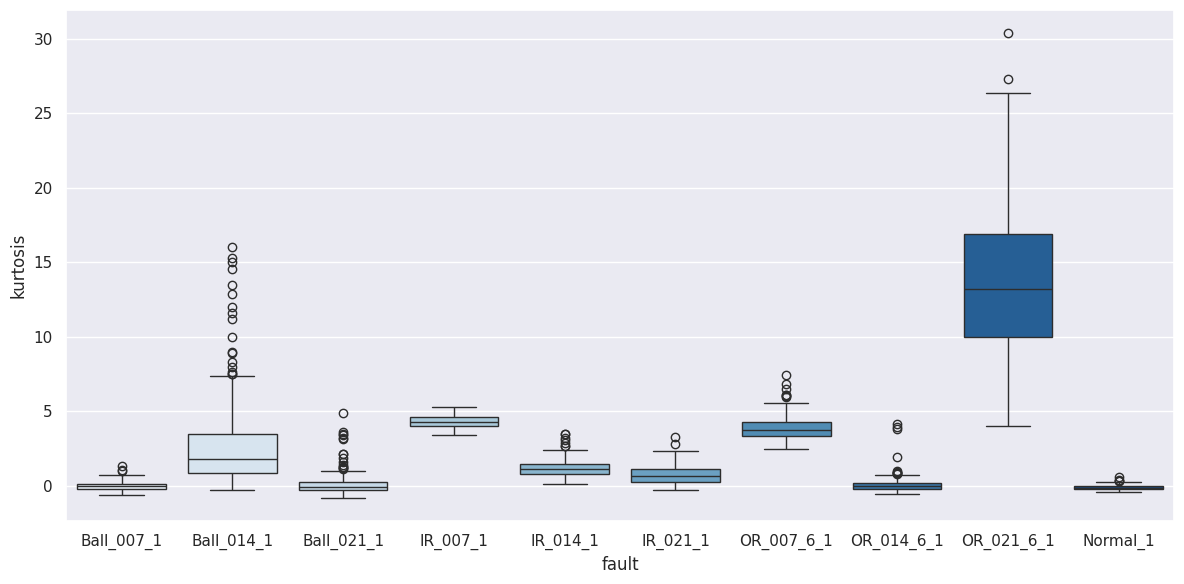

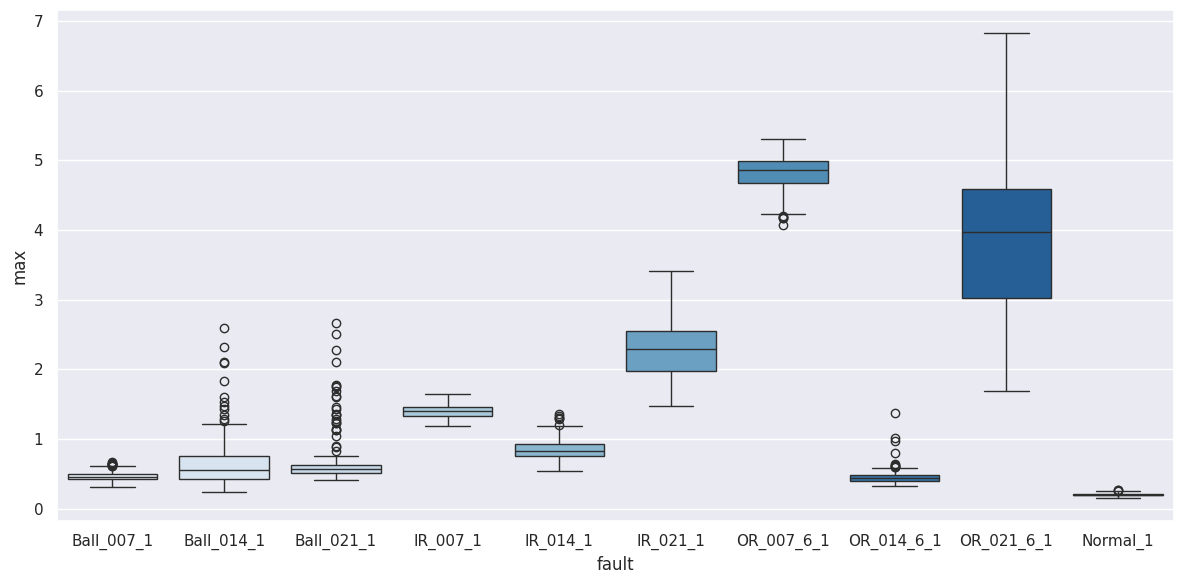

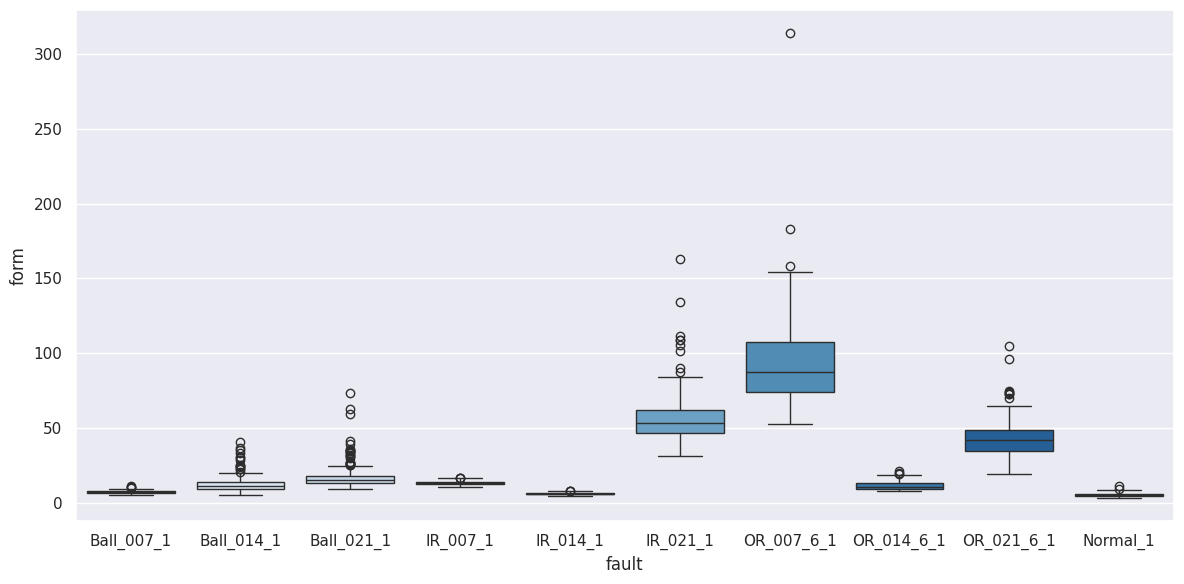

In [31]:
pairs = ['skewness', 'crest', 'rms', 'kurtosis', 'max', 'form']

for i in pairs:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data = df_clean, hue=target_col, x=target_col, y=i, legend=False, palette='Blues')
    plt.savefig(IMG_PATH + f'figure_{i}_boxplot.png', dpi=150, bbox_inches='tight', pad_inches=0.05)
    plt.tight_layout()
    plt.show()

In [32]:
df.groupby("fault")["rms"].agg(
    min_val="min",
    q25=lambda x: x.quantile(0.25),
    q50="median",   # или x.quantile(0.5)
    q75=lambda x: x.quantile(0.75),
    max_val="max",
    mean_val="mean"
)

,min_val,q25,q50,q75,max_val,mean_val
fault,,,,,,
Ball_007_1,0.1177,0.1347,0.1399,0.1471,0.1730,0.1409
Ball_014_1,0.0788,0.1063,0.1258,0.1542,0.3701,0.1384
Ball_021_1,0.1359,0.1674,0.1792,0.1916,0.6713,0.2000
IR_007_1,0.2570,0.2722,0.2776,0.2862,0.3016,0.2786
IR_014_1,0.1625,0.1861,0.1955,0.2072,0.2417,0.1971
IR_021_1,0.4611,0.5658,0.6043,0.6467,0.7600,0.6058
Normal_1,0.0611,0.0647,0.0662,0.0678,0.0731,0.0663
OR_007_6_1,0.8496,1.0059,1.0576,1.1045,1.2563,1.0564
OR_014_6_1,0.1110,0.1281,0.1349,0.1417,0.2605,0.1364


# $Фильтрация\;данных$

In [33]:
print("\n=== Анализ выбросов до фильтрации (clipping) ===")

df_before = df_clean.copy()

df_after = df_before.copy()

stats_list = []

for col in STRICT_COLS:
    low = df_before[col].quantile(CLIP_STRICT[0])
    high = df_before[col].quantile(CLIP_STRICT[1])
    
    below = (df_before[col] < low).sum()
    above = (df_before[col] > high).sum()
    total_changed = below + above
    
    if total_changed > 0:
        max_below_dev = (low - df_before[col][df_before[col] < low]).max() if below > 0 else 0
        max_above_dev = (df_before[col][df_before[col] > high] - high).max() if above > 0 else 0
    else:
        max_below_dev = 0
        max_above_dev = 0
    
    stats_list.append({
        'Признак': col,
        'Граница low': round(low, 4),
        'Граница high': round(high, 4),
        'Ниже low': below,
        'Выше high': above,
        'Всего изменено': total_changed,
        'Доля от выборки, %': round(total_changed / len(df_before) * 100, 2),
        'Макс. отклонение снизу': round(max_below_dev, 4),
        'Макс. отклонение сверху': round(max_above_dev, 4)
    })
    
    df_after[col] = df_before[col].clip(low, high)

for col in SOFT_COLS:
    low = df_before[col].quantile(CLIP_SOFT[0])
    high = df_before[col].quantile(CLIP_SOFT[1])
    
    below = (df_before[col] < low).sum()
    above = (df_before[col] > high).sum()
    total_changed = below + above
    
    if total_changed > 0:
        max_below_dev = (low - df_before[col][df_before[col] < low]).max() if below > 0 else 0
        max_above_dev = (df_before[col][df_before[col] > high] - high).max() if above > 0 else 0
    else:
        max_below_dev = 0
        max_above_dev = 0
    
    stats_list.append({
        'Признак': col,
        'Граница low': round(low, 4),
        'Граница high': round(high, 4),
        'Ниже low': below,
        'Выше high': above,
        'Всего изменено': total_changed,
        'Доля от выборки, %': round(total_changed / len(df_before) * 100, 2),
        'Макс. отклонение снизу': round(max_below_dev, 4),
        'Макс. отклонение сверху': round(max_above_dev, 4)
    })
    
    df_after[col] = df_before[col].clip(low, high)

stats_df = pd.DataFrame(stats_list)
print("\nТаблица 4. Результаты фильтрации (clipping) по признакам")
print(stats_df.to_string(index=False))

print("\n=== Сравнение средних значений до и после фильтрации ===")
comparison = []
for col in feature_cols:
    mean_before = df_before[col].mean()
    mean_after = df_after[col].mean()
    change = mean_after - mean_before
    change_pct = (change / mean_before) * 100 if mean_before != 0 else 0
    comparison.append({
        'Признак': col,
        'Среднее до': round(mean_before, 4),
        'Среднее после': round(mean_after, 4),
        'Абс. изменение': round(change, 6),
        'Отн. изменение, %': round(change_pct, 4)
    })
comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

df_filtered = df_after
print(f"\nРазмер данных после фильтрации: {df_filtered.shape} (не изменился)")


=== Анализ выбросов до фильтрации (clipping) ===

Таблица 4. Результаты фильтрации (clipping) по признакам
 Признак  Граница low  Граница high  Ниже low  Выше high  Всего изменено  Доля от выборки, %  Макс. отклонение снизу  Макс. отклонение сверху
    mean       0.0073        0.0337        23         23              46              2.0000                  0.0041                   0.0047
      sd       0.0621        1.1560        23         23              46              2.0000                  0.0030                   0.1006
     rms       0.0635        1.1558        23         23              46              2.0000                  0.0025                   0.1005
     max       0.1777        5.8305        11         12              23              1.0000                  0.0204                   0.9954
     min      -5.5590       -0.1763        12         12              24              1.0400                  0.7336                   0.0161
skewness      -0.8622        0.3838     

# $Добавление\;шума$


Таблица 5. RMSE между исходными и зашумлёнными признаками (усреднённый по всем признакам)
 Уровень шума (σ/σ_признака)  Средний RMSE
                      0.0100        0.0439
                      0.0500        0.2209
                      0.1000        0.4321


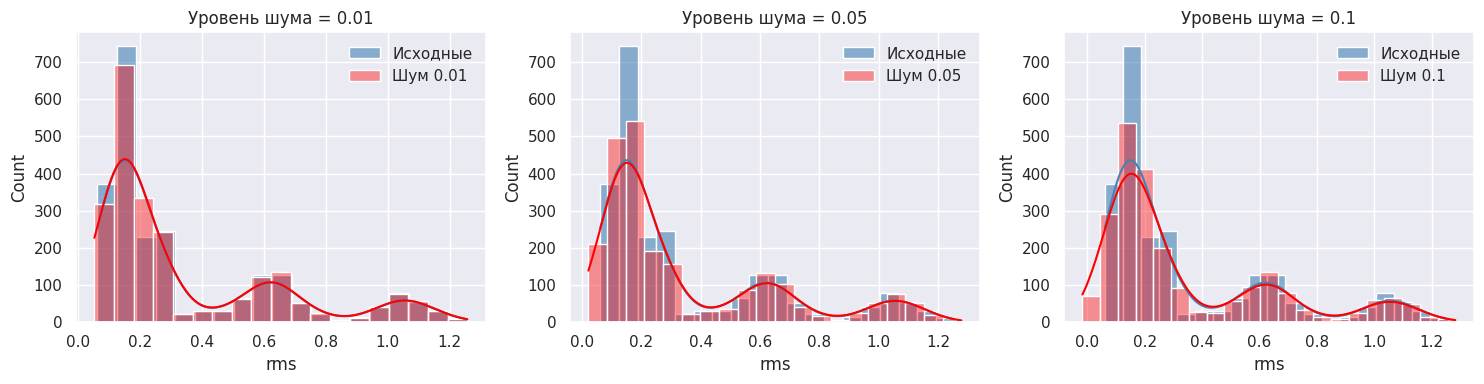

In [35]:
def add_gaussian_noise(data, columns, noise_level=0.05):
    """Добавляет гауссовский шум с нулевым средним и std = noise_level * std(признака)"""
    noisy = data.copy()
    for col in columns:
        std = data[col].std()
        noise = np.random.normal(0, noise_level * std, size=len(data))
        noisy[col + '_noisy'] = data[col] + noise
    return noisy

rmse_results = []
df_final= df
for level in NOISE_LEVELS:
    df_noisy = add_gaussian_noise(df_final, feature_cols, noise_level=level)
    rmse_list = []
    for col in feature_cols:
        rmse = np.sqrt(np.mean((df_final[col] - df_noisy[col + '_noisy'])**2))
        rmse_list.append(rmse)
    avg_rmse = np.mean(rmse_list)
    rmse_results.append({'Уровень шума (σ/σ_признака)': level, 'Средний RMSE': avg_rmse})

rmse_table = pd.DataFrame(rmse_results)
print("\nТаблица 5. RMSE между исходными и зашумлёнными признаками (усреднённый по всем признакам)")
print(rmse_table.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, level in enumerate(NOISE_LEVELS):
    df_noisy = add_gaussian_noise(df_final, ['rms'], noise_level=level)
    sns.histplot(df_final['rms'], kde=True, ax=axes[i], color='steelblue', label='Исходные', alpha=0.6)
    sns.histplot(df_noisy['rms_noisy'], kde=True, ax=axes[i], color='red', label=f'Шум {level}', alpha=0.4)
    axes[i].set_title(f'Уровень шума = {level}')
    axes[i].set_xlabel('rms')
    axes[i].legend()
plt.tight_layout()
plt.savefig(IMG_PATH + 'figure_5_RMS_noise_histograms.png', dpi=150)
plt.show()